In [21]:
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage
from typing import Union

messages: list[Union[AIMessage, HumanMessage, AnyMessage]] = [AIMessage(f"So you said you were researching ocean mammals?", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about?", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, I know about whales. But what others should I learn about?


In [22]:
from langchain_openai.chat_models import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")
llm.invoke(messages)

AIMessage(content='In addition to whales, there are several fascinating ocean mammals you might want to explore:\n\n1. **Dolphins**: Known for their intelligence and playful behavior, dolphins are social animals that often live in pods. The bottlenose dolphin is one of the most well-known species.\n\n2. **Porpoises**: Similar to dolphins but generally smaller and with different teeth, porpoises are less social and prefer calmer waters.\n\n3. **Seals**: There are various species of seals, such as harbor seals and elephant seals. They are known for their smooth bodies and playful nature.\n\n4. **Sea Lions**: Often found in more temperate regions, sea lions are known for their ability to walk on land and have a more social behavior compared to seals.\n\n5. **Manatees**: Sometimes called "sea cows," manatees are gentle herbivores that inhabit warm coastal waters and rivers.\n\n6. **Dugongs**: Similar to manatees, dugongs are another type of marine herbivore found in warm coastal waters but

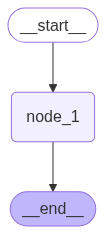

In [23]:
from IPython.display import display, Image, Markdown
from langgraph.graph import START, END, StateGraph, MessagesState

def node_1(state: MessagesState):
    print("---Node 1---")
    return {"messages": llm.invoke(state["messages"])}

builder = StateGraph(MessagesState)

builder.add_node("node_1", node_1)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
output = graph.invoke({"messages": messages})

---Node 1---


In [25]:
for m in output["messages"]:
    display(Markdown(m.content))

So you said you were researching ocean mammals?

Yes, I know about whales. But what others should I learn about?

In addition to whales, there are several other fascinating ocean mammals you might want to learn about:

1. **Dolphins** - Known for their intelligence and playful behavior, there are many species of dolphins, including the bottlenose dolphin and the orca (killer whale), which is actually a dolphin species.

2. **Porpoises** - Similar to dolphins but generally smaller and with different teeth and snouts, porpoises are less acrobatic but just as interesting.

3. **Seals** - There are two main types: earless seals (true seals) and earred seals (eared seals), such as sea lions. Seals are known for their playful behavior and their ability to thrive in various marine environments.

4. **Sea Lions** - These are social animals often found in large groups, known for their barking calls and impressive swimming abilities.

5. **Manatees** - Sometimes called "sea cows," these gentle herbivores inhabit coastal waters and rivers and are known for their slow-moving and peaceful nature.

6. **Dugongs** - Similar to manatees, dugongs are marine herbivores found in warm coastal waters, mostly in the Indian and western Pacific Oceans.

7. **Narwhals** - Often referred to as the "unicorns of the sea," these Arctic whales are known for their long, spiral tusks, which are actually elongated teeth.

8. **Beluga Whales** - Known for their white color and vocalizations, beluga whales are sometimes called the "canaries of the sea" due to their various sounds.

9. **Sea Otters** - Although smaller than many marine mammals, sea otters play a crucial role in their ecosystem and are known for their use of tools to open shells.

10. **Walruses** - With their distinctive tusks, walruses are found in the Arctic and are known for their social behavior and ability to dive to great depths.

Each of these mammals has unique behaviors, adaptations, and ecological roles, making them all worth studying!

In [26]:
from langchain_core.messages import RemoveMessage

# node
def filter_msg(state: MessagesState):
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2] if m.id is not None]
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState):
    return {"messages": llm.invoke(state["messages"])}

In [27]:
builder = StateGraph(MessagesState)

builder.add_node("filter_msg", filter_msg)
builder.add_node("chat_model_node", chat_model_node)

builder.add_edge(START, "filter_msg")
builder.add_edge("filter_msg", "chat_model_node")
builder.add_edge("chat_model_node", END)

graph = builder.compile()

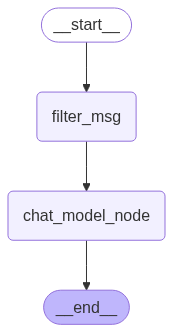

In [28]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
# Message list with a preamble
messages: list[Union[AIMessage, HumanMessage, AnyMessage]] = [AIMessage("Hi.", name="Bot", id="1")]
messages.append(HumanMessage("Hi.", name="Lance", id="2"))
messages.append(AIMessage("So you said you were researching ocean mammals?", name="Bot", id="3"))
messages.append(HumanMessage("Yes, I know about whales. But what others should I learn about?", name="Lance", id="4"))

In [31]:
# Invoke
for m in messages:
    display(Markdown(m.content))

Hi.

Hi.

So you said you were researching ocean mammals?

Yes, I know about whales. But what others should I learn about?

In [30]:
# Invoke
output = graph.invoke({'messages': messages})
for m in output['messages']:
    display(Markdown(m.content))

So you said you were researching ocean mammals?

Yes, I know about whales. But what others should I learn about?

In addition to whales, there are several fascinating ocean mammals you can learn about:

1. **Dolphins**: Known for their intelligence and playful behavior, dolphins are social animals that belong to the cetacean family, like whales.

2. **Porpoises**: Similar to dolphins but generally smaller and with a different snout shape, porpoises are also part of the cetacean family.

3. **Seals**: These pinnipeds are marine mammals that are characterized by their flippers. They include species like harbor seals and elephant seals.

4. **Sea Lions**: Similar to seals, sea lions are also pinnipeds but are distinguished by their external ear flaps and more social behavior.

5. **Manatees** (or "sea cows"): These gentle herbivorous mammals inhabit warm coastal waters and rivers. They're known for their slow-moving nature.

6. **Dugongs**: Closely related to manatees, dugongs are also herbivorous marine mammals found primarily in warm coastal waters.

7. **Narwhals**: Known for their long, spiral tusks, narwhals inhabit Arctic waters and are also a type of whale.

8. **Beluga Whales**: These small white whales are known for their vocalizations and are often called "canaries of the sea."

9. **Orcas** (or killer whales): These highly social and intelligent whales are actually the largest members of the dolphin family and have complex social structures.

10. **Polar Bears**: While primarily terrestrial, they are classified as marine mammals because they spend much of their life on the sea ice of the Arctic Ocean, hunting seals.

These marine mammals showcase a range of behaviors, adaptations, and habitats, making them all unique and worth studying!

We can also use the Trim Message function manage the history of the messages.

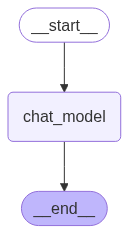

In [38]:
from langchain_core.messages import trim_messages

# Node
def chat_model_node(state: MessagesState):
    messages = trim_messages(
            state["messages"],
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-4o-mini"),
            allow_partial=False,
        )
    return {"messages": [llm.invoke(messages)]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("chat_model", chat_model_node)
builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
messages.append(output['messages'][-1])
messages.append(HumanMessage(f"Tell me where Orcas live!", name="Lance"))

In [40]:
# Example of trimming messages
trim_messages(
            messages,
            max_tokens=100,
            strategy="last",
            token_counter=ChatOpenAI(model="gpt-4o-mini"),
            allow_partial=False
        )

[HumanMessage(content='Tell me where Orcas live!', additional_kwargs={}, response_metadata={}, name='Lance')]

In [41]:
messages_out_trim = graph.invoke({'messages': messages})


In [42]:
# Invoke
for m in messages_out_trim['messages']:
    display(Markdown(m.content))

Hi.

Hi.

So you said you were researching ocean mammals?

Yes, I know about whales. But what others should I learn about?

In addition to whales, there are several fascinating ocean mammals you can learn about:

1. **Dolphins**: Known for their intelligence and playful behavior, dolphins are social animals that belong to the cetacean family, like whales.

2. **Porpoises**: Similar to dolphins but generally smaller and with a different snout shape, porpoises are also part of the cetacean family.

3. **Seals**: These pinnipeds are marine mammals that are characterized by their flippers. They include species like harbor seals and elephant seals.

4. **Sea Lions**: Similar to seals, sea lions are also pinnipeds but are distinguished by their external ear flaps and more social behavior.

5. **Manatees** (or "sea cows"): These gentle herbivorous mammals inhabit warm coastal waters and rivers. They're known for their slow-moving nature.

6. **Dugongs**: Closely related to manatees, dugongs are also herbivorous marine mammals found primarily in warm coastal waters.

7. **Narwhals**: Known for their long, spiral tusks, narwhals inhabit Arctic waters and are also a type of whale.

8. **Beluga Whales**: These small white whales are known for their vocalizations and are often called "canaries of the sea."

9. **Orcas** (or killer whales): These highly social and intelligent whales are actually the largest members of the dolphin family and have complex social structures.

10. **Polar Bears**: While primarily terrestrial, they are classified as marine mammals because they spend much of their life on the sea ice of the Arctic Ocean, hunting seals.

These marine mammals showcase a range of behaviors, adaptations, and habitats, making them all unique and worth studying!

Tell me where Orcas live!

Tell me where Orcas live!

Orcas, also known as killer whales, inhabit oceans around the world, from the polar regions to tropical waters. They are most commonly found in coastal and continental shelf areas but can also be found in deep oceanic waters. Here are some specific locations where orcas are known to thrive:

1. **Pacific Northwest**: The waters off the coasts of Washington State and British Columbia are well-known for resident orca pods, particularly the Southern Resident orcas.

2. **Norway and Iceland**: These regions are popular for their seasonal orca populations that follow herring migrations.

3. **Antarctica**: Orcas are often found in the icy waters around the Antarctic, where they hunt seals and other marine animals.

4. **California**: Orcas can also be spotted along the California coast, especially during certain times of the year when they follow prey.

5. **New Zealand**: Orcas are known to inhabit waters around New Zealand, particularly in the Bay of Islands and other coastal areas.

Overall, their wide distribution is a reflection of their adaptability to various marine environments.